# Project : Loan Approval System

Built an end-to-end supervised ML pipeline to predict loan approval using
- KNN
- Logistic Regression
- Naive Bayes
  
Implemented Binary classification along with EDA, feature engineering & model evaluation (Precision, Recall, F1).

## Importing Libraries and basic Dataset overview 

In [26]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [27]:
df = pd.read_csv("loan_approval_data (1).csv")

In [28]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


## Handle Missing Values

- There are almost 50 missing values in each column
- So we divide the df into categorical and numerical columns
- Then impute the values strategically 

In [29]:
# selecting the categorical attributes/columns 

cat_cols = df.select_dtypes(include = ["object"]).columns
cat_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [30]:
# selecting the numerical attributes/columns

num_cols = df.select_dtypes(include = ["float64"]).columns 
num_cols

# we can write for all numerical values with keyword "number"
# num_cols = df.select_dtypes(include = ["float64", "int64"]).columns
#                  ||
#                  V
# num_cols = df.select_dtypes(include = ["number"]).columns 



Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [31]:
# to cross check the size of the cols

cat_cols.size + num_cols.size # should be 20

20

In [32]:
# SimpleImputer is used to substitute the strategic values such as mean, median, mode etc to NULL/NAN values
from sklearn.impute import SimpleImputer


cat_imp = SimpleImputer(strategy = "most_frequent") # for categorical columns we impute mean 
df[cat_cols] = cat_imp.fit_transform(df[cat_cols])


num_imp = SimpleImputer(strategy = "mean") # for numerical columns we impute most frequent
df[num_cols] = num_imp.fit_transform(df[num_cols]) 

df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## EDA - Exploratory Data Analysis

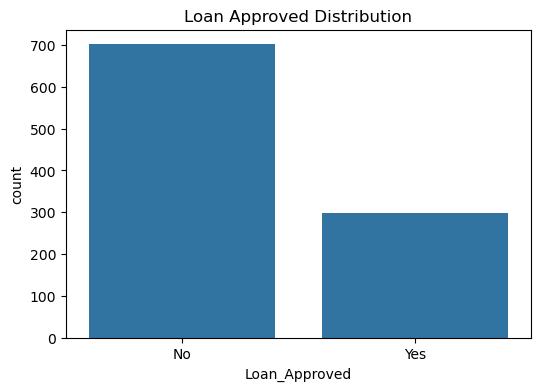

Class Distribution Percentage:
Loan_Approved
No     70.2
Yes    29.8
Name: proportion, dtype: float64


In [33]:
# How many loans were Approved vs Rejected
plt.figure(figsize=(6,4))
sns.countplot(x="Loan_Approved", data=df)
plt.title("Loan Approved Distribution")
plt.show()

print("Class Distribution Percentage:")
print(df["Loan_Approved"].value_counts(normalize=True) * 100)

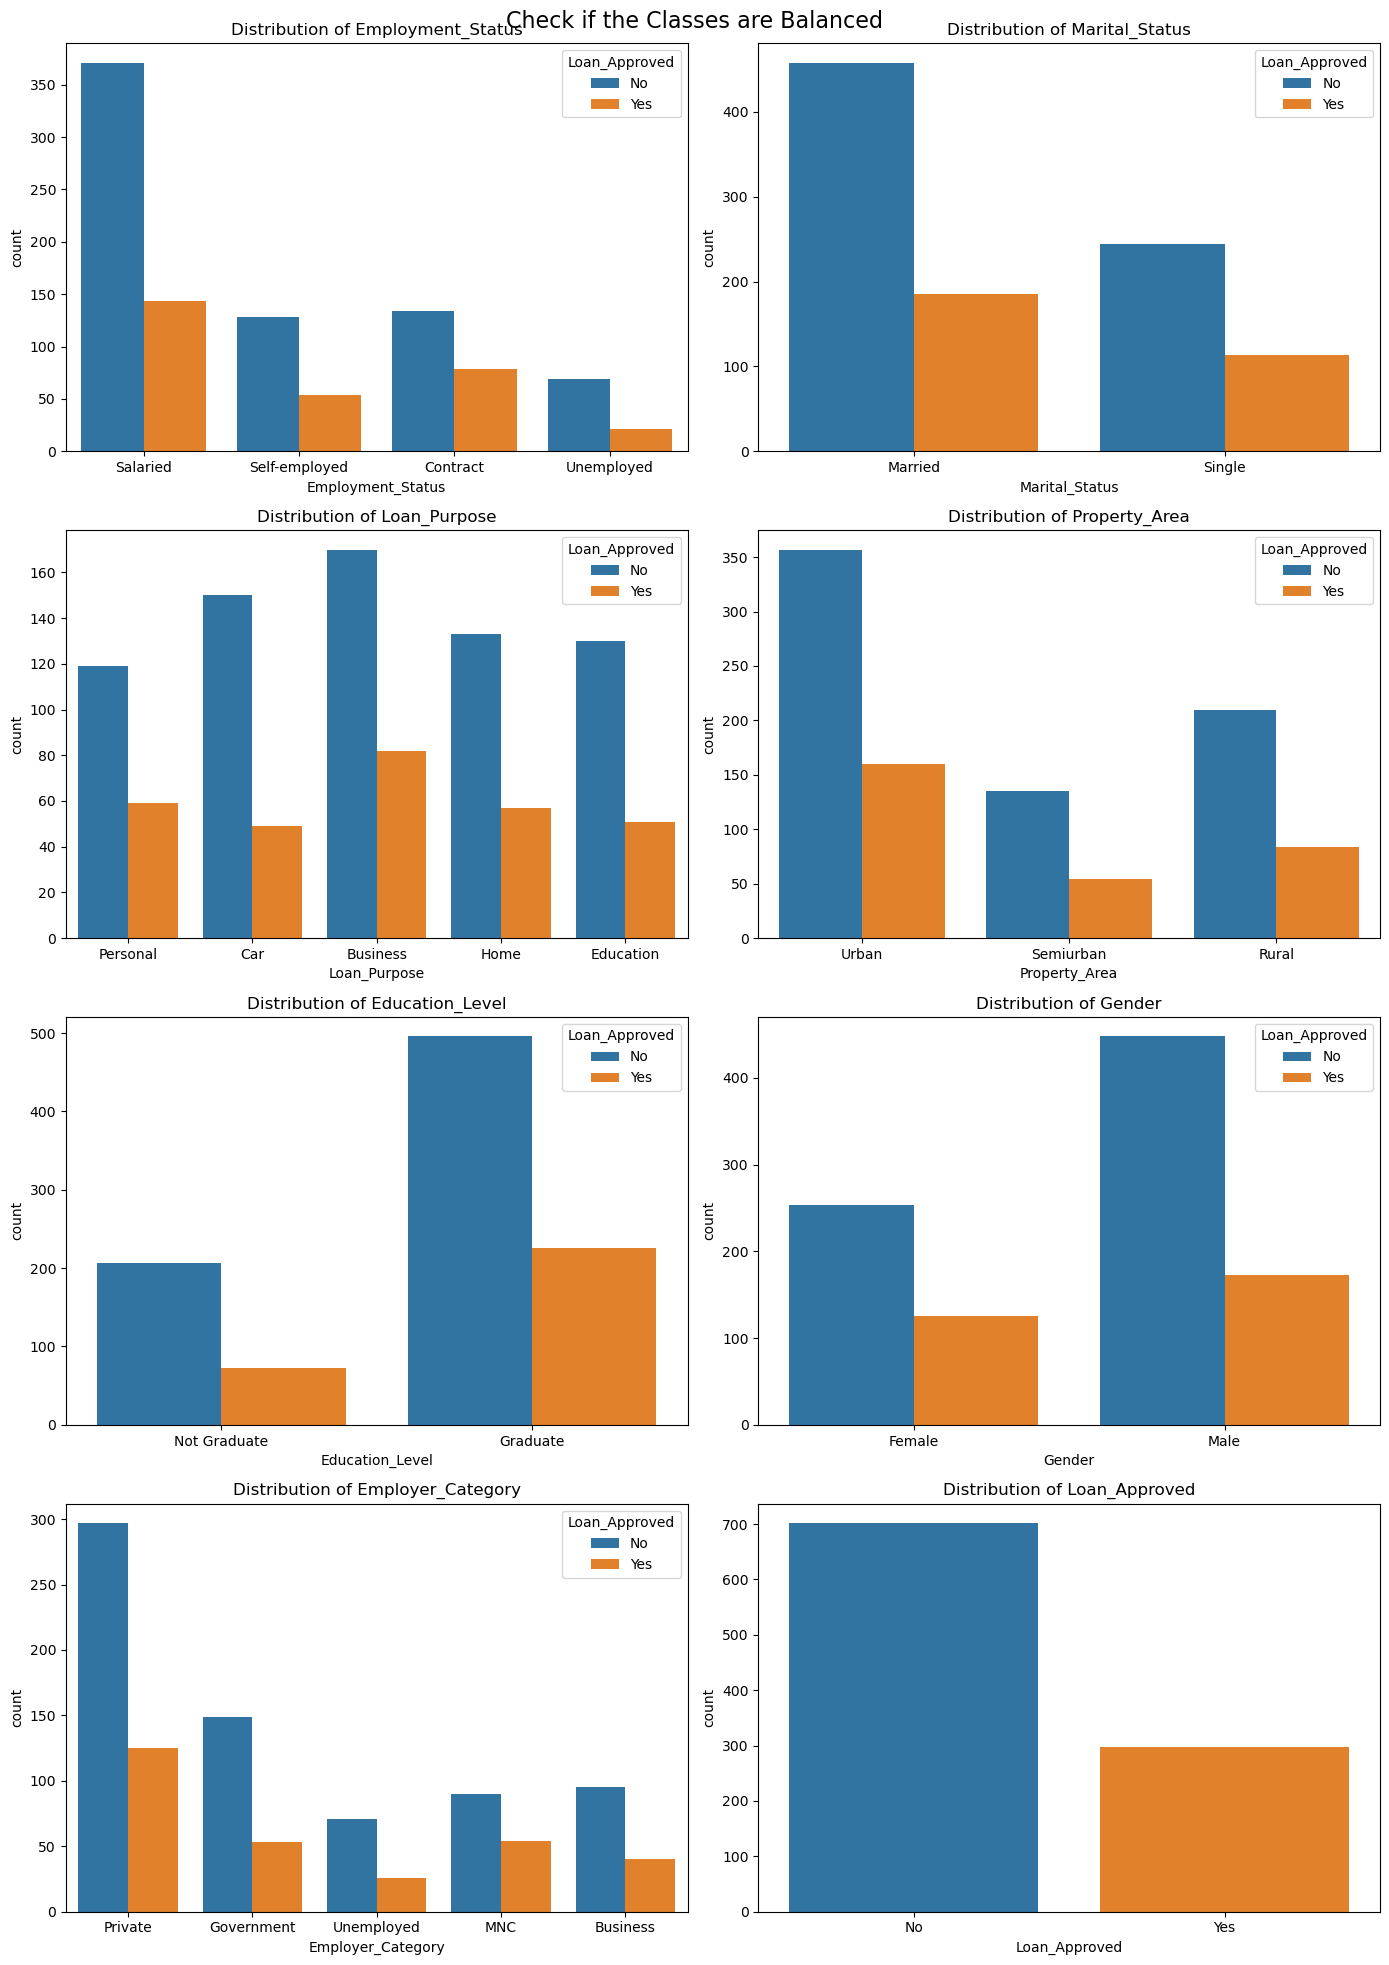

In [34]:
# First we check how much balanced are our Classes
# so we make a store the count of the cateories and then plot

cat_cols.size # 8
cat_cols # ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
#       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved']

n_cols = 2                               # 2 plots per row (clean view)
n_rows = (len(cat_cols) + 1) // n_cols   # auto calculate rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i] , hue = "Loan_Approved")
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
#    axes[i].tick_params(axis='x', rotation=45)

# Remove extra empty plots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Check if the Classes are Balanced", fontsize=16)
plt.tight_layout()
plt.show()



<Axes: xlabel='Applicant_Income', ylabel='Loan_Amount'>

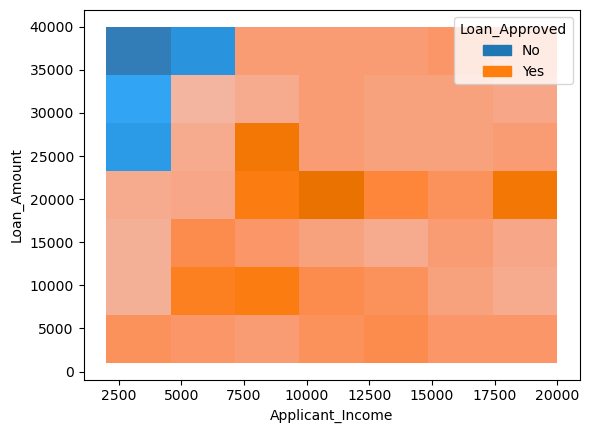

In [35]:
sns.histplot( data = df , x = "Applicant_Income" , y = "Loan_Amount" , hue = "Loan_Approved" , bins = 7 )

<Axes: xlabel='Credit_Score', ylabel='Count'>

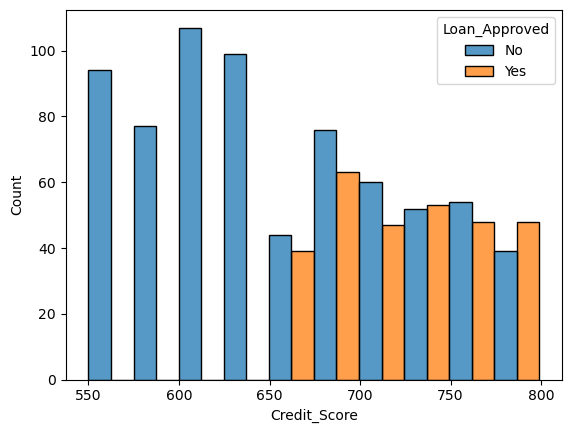

In [36]:
sns.histplot( data = df , x = "Credit_Score" , hue = "Loan_Approved" , bins = 10  , multiple =  "dodge")

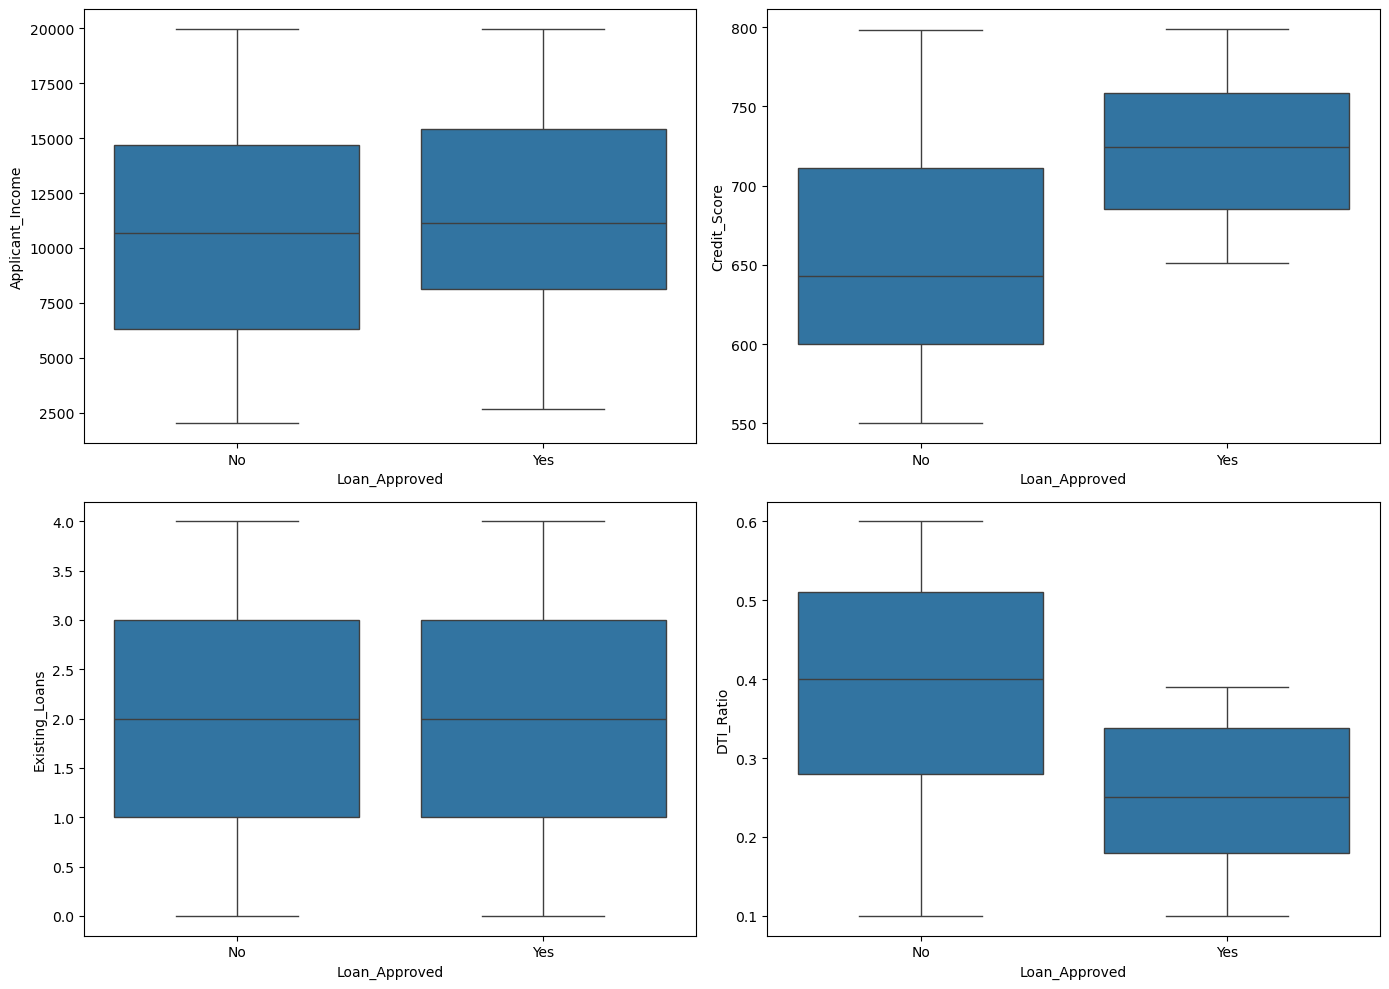

In [37]:
# To check outliers
fig , axes = plt.subplots( 2, 2 , figsize = (14 , 5*2))
sns.boxplot( data = df , y =  "Applicant_Income" , x = "Loan_Approved" , ax = axes[0][0] )
sns.boxplot( data = df , y =  "Credit_Score" , x = "Loan_Approved" , ax = axes[0][1] )
sns.boxplot( data = df , y =  "Existing_Loans" , x = "Loan_Approved" , ax = axes[1][0] )
sns.boxplot( data = df , y =  "DTI_Ratio" , x = "Loan_Approved" , ax = axes[1][1] )

plt.tight_layout()

## Encoding 

In [41]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# label encoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

# OHE
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe = OneHotEncoder(drop = "first" , sparse_output = False , handle_unknown= 'ignore')

encoded = ohe.fit_transform(df[cols])

edf = pd.DataFrame( encoded , columns = ohe.get_feature_names_out(cols),index = df.index)
df = pd.concat([ df.drop(columns = cols), edf ], axis = 1)

In [48]:
df = df.drop(columns = "Applicant_ID")

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

## Correlation Heatmap

In [64]:
num_cols = df.select_dtypes( include = "number")
corr_matrix = num_cols.corr()

In [67]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

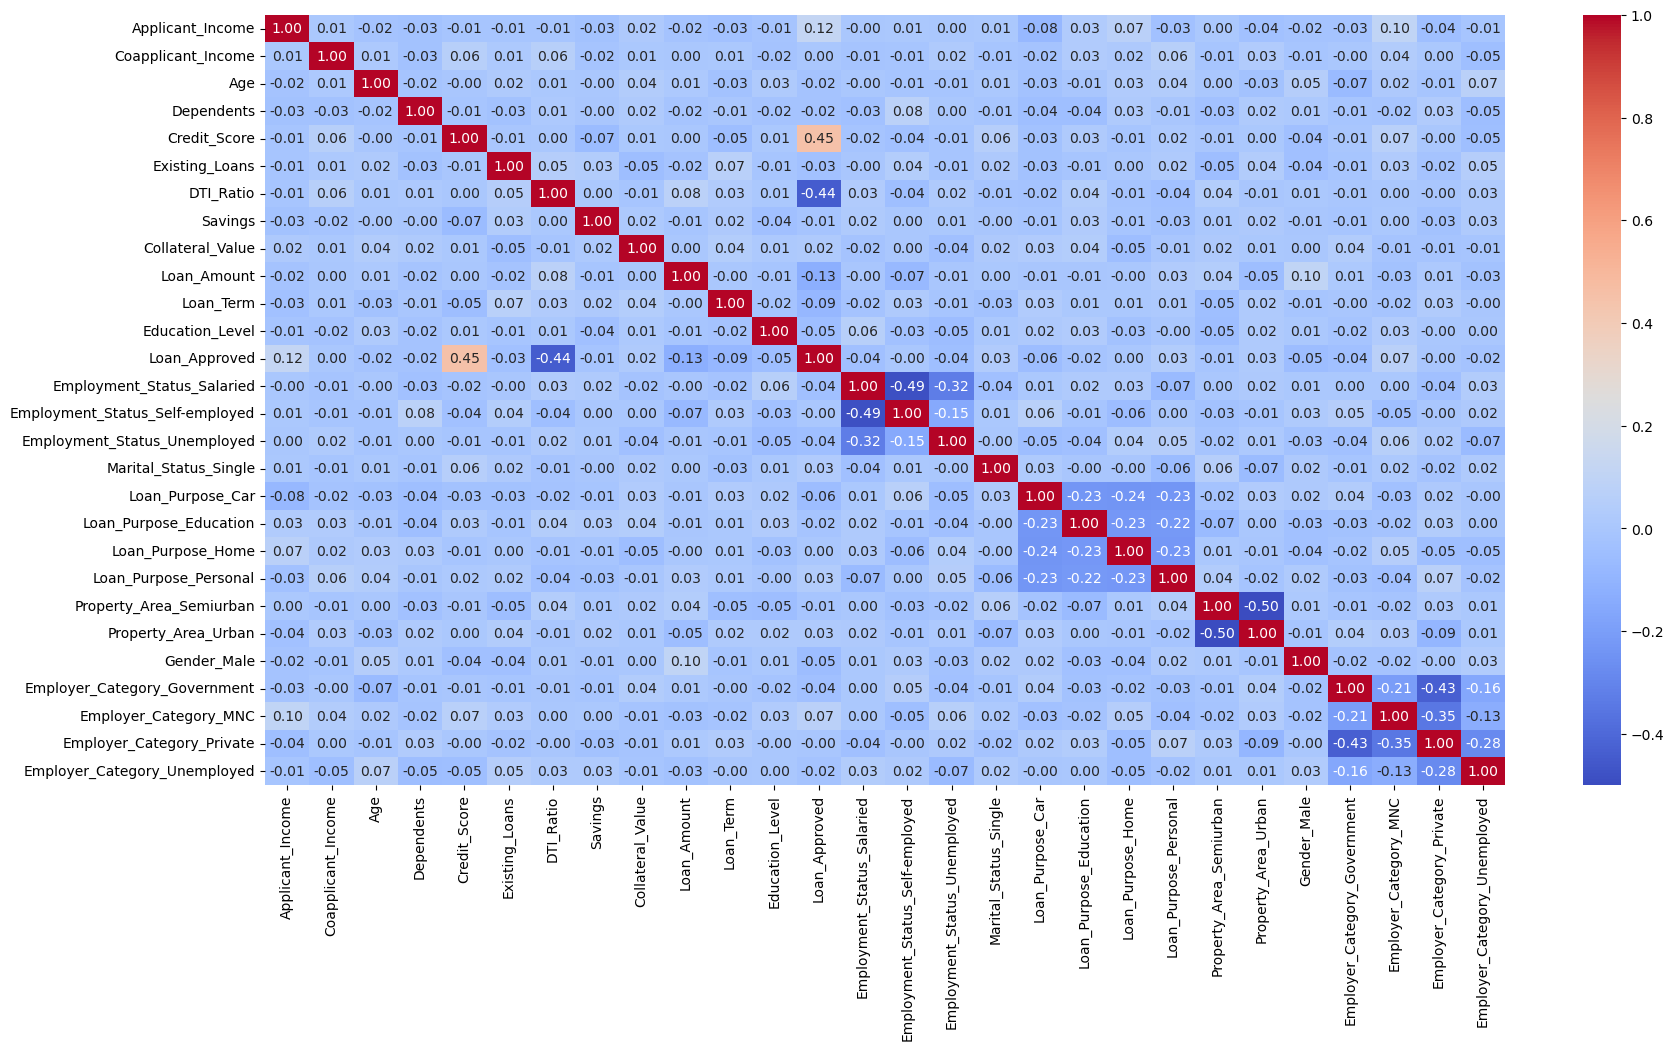

In [68]:

plt.figure(figsize = ( 20 , 10))
sns.heatmap(
    corr_matrix ,
    annot = True ,
    fmt = ".2f" , 
    cmap = "coolwarm")
    

## Train-test Split and Scaling 

In [69]:
X = df.drop("Loan_Approved" , axis = 1)
y = df["Loan_Approved"]

In [71]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [72]:

X_train, X_test , y_train, y_test = train_test_split( X , y , test_size = 0.75 , random_state = 42 )


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train and Evaluate models

In [80]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score , accuracy_score , recall_score , f1_score , confusion_matrix


log_model = LogisticRegression()
log_model.fit( X_train_scaled , y_train)

y_pred = log_model.predict(X_test_scaled)

print("Logistic Regression : ")
print(f"Precision Score : {precision_score(y_test , y_pred)}")
print(f"Recall Score : {recall_score(y_test , y_pred)}")
print(f"F1 Score : {f1_score(y_test , y_pred)}")
print(f"Accuracy Score : {accuracy_score(y_test , y_pred)}")
print(f"Confusion Matrix : \n{confusion_matrix(y_test , y_pred)}")


Logistic Regression : 
Precision Score : 0.7688172043010753
Recall Score : 0.6190476190476191
F1 Score : 0.6858513189448441
Accuracy Score : 0.8253333333333334
Confusion Matrix : 
[[476  43]
 [ 88 143]]


In [98]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score , accuracy_score , recall_score , f1_score , confusion_matrix


knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit( X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

print("KNeighborsClassifier : ")
print(f"Precision Score : {precision_score(y_test , y_pred)}")
print(f"Recall Score : {recall_score(y_test , y_pred)}")
print(f"F1 Score : {f1_score(y_test , y_pred)}")
print(f"Accuracy Score : {accuracy_score(y_test , y_pred)}")
print(f"Confusion Matrix : \n{confusion_matrix(y_test , y_pred)}")


KNeighborsClassifier : 
Precision Score : 0.656
Recall Score : 0.354978354978355
F1 Score : 0.4606741573033708
Accuracy Score : 0.744
Confusion Matrix : 
[[476  43]
 [149  82]]


In [99]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score , accuracy_score , recall_score , f1_score , confusion_matrix


NB_model = GaussianNB()
NB_model.fit( X_train_scaled , y_train)

y_pred = NB_model.predict(X_test_scaled)

print("GaussianNB : ")
print(f"Precision Score : {precision_score(y_test , y_pred)}")
print(f"Recall Score : {recall_score(y_test , y_pred)}")
print(f"F1 Score : {f1_score(y_test , y_pred)}")
print(f"Accuracy Score : {accuracy_score(y_test , y_pred)}")
print(f"Confusion Matrix : \n{confusion_matrix(y_test , y_pred)}")

GaussianNB : 
Precision Score : 0.8187134502923976
Recall Score : 0.6060606060606061
F1 Score : 0.6965174129353234
Accuracy Score : 0.8373333333333334
Confusion Matrix : 
[[488  31]
 [ 91 140]]


###       We conclude that **Naive Bayes** is best model 

## More Feature Engineering to improve model

In [94]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# for skewed data
# df["Applicant_Income"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns = ["DTI_Ratio","Credit_Score","Loan_Approved"])
y = df["Loan_Approved"]


In [95]:
X_train, X_test , y_train, y_test = train_test_split( X , y , test_size = 0.75 , random_state = 42 )

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score , accuracy_score , recall_score , f1_score , confusion_matrix


log_model = LogisticRegression()
log_model.fit( X_train_scaled , y_train)

y_pred = log_model.predict(X_test_scaled)

print("Logistic Regression : ")
print(f"Precision Score : {precision_score(y_test , y_pred)}")
print(f"Recall Score : {recall_score(y_test , y_pred)}")
print(f"F1 Score : {f1_score(y_test , y_pred)}")
print(f"Accuracy Score : {accuracy_score(y_test , y_pred)}")
print(f"Confusion Matrix : \n{confusion_matrix(y_test , y_pred)}")

Logistic Regression : 
Precision Score : 0.7795698924731183
Recall Score : 0.6277056277056277
F1 Score : 0.6954436450839329
Accuracy Score : 0.8306666666666667
Confusion Matrix : 
[[478  41]
 [ 86 145]]


In [97]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score , accuracy_score , recall_score , f1_score , confusion_matrix


knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit( X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

print("KNeighborsClassifier : ")
print(f"Precision Score : {precision_score(y_test , y_pred)}")
print(f"Recall Score : {recall_score(y_test , y_pred)}")
print(f"F1 Score : {f1_score(y_test , y_pred)}")
print(f"Accuracy Score : {accuracy_score(y_test , y_pred)}")
print(f"Confusion Matrix : \n{confusion_matrix(y_test , y_pred)}")


Logistic Regression : 
Precision Score : 0.656
Recall Score : 0.354978354978355
F1 Score : 0.4606741573033708
Accuracy Score : 0.744
Confusion Matrix : 
[[476  43]
 [149  82]]


In [100]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score , accuracy_score , recall_score , f1_score , confusion_matrix


NB_model = GaussianNB()
NB_model.fit( X_train_scaled , y_train)

y_pred = NB_model.predict(X_test_scaled)

print("GaussianNB : ")
print(f"Precision Score : {precision_score(y_test , y_pred)}")
print(f"Recall Score : {recall_score(y_test , y_pred)}")
print(f"F1 Score : {f1_score(y_test , y_pred)}")
print(f"Accuracy Score : {accuracy_score(y_test , y_pred)}")
print(f"Confusion Matrix : \n{confusion_matrix(y_test , y_pred)}")

GaussianNB : 
Precision Score : 0.8187134502923976
Recall Score : 0.6060606060606061
F1 Score : 0.6965174129353234
Accuracy Score : 0.8373333333333334
Confusion Matrix : 
[[488  31]
 [ 91 140]]
